In [3]:
# 1. Import
import pandas as pd

In [4]:
# 2. Load master table v1
df_master = pd.read_csv(
    "../data/processed/master_table_tainan_2024_v1.csv"
)

In [5]:
# 3. Create analysis indicators
df_master["pt_per_10000"] = (
    df_master["pt_count"]
    / df_master["total_population"]
    * 10000
)

df_master["pt_per_10000_65plus"] = (
    df_master["pt_count"]
    / df_master["population_65_plus"]
    * 10000
)

df_master["rehab_medical_facility_count"] = (
    df_master["rehab_clinic_count"]
    + df_master["rehab_hospital_count"]
)

df_master["rehab_medical_facility_per_10000"] = (
    df_master["rehab_medical_facility_count"]
    / df_master["total_population"]
    * 10000
)

In [6]:
df_master[
    [
        "district",
        "pt_per_10000",
        "pt_per_10000_65plus",
        "rehab_medical_facility_count",
        "rehab_medical_facility_per_10000"
    ]
].head().round(2)

,district,pt_per_10000,pt_per_10000_65plus,rehab_medical_facility_count,rehab_medical_facility_per_10000
0,新營區,3.48,16.64,5,0.67
1,鹽水區,0.00,0.00,0,0.00
2,白河區,1.18,4.10,1,0.39
3,柳營區,12.98,52.70,1,0.50
4,後壁區,0.94,3.21,0,0.00


In [7]:
df_master.head()
df_master.shape

(37, 11)

In [7]:
#把目前記憶體裡已經多了 4 個新指標的 df_master，另外輸出成一份新 CSV
df_master.to_csv(
    "../data/processed/master_table_tainan_2024_v2.csv",
    index=False,
    encoding="utf-8-sig"
)

In [11]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Microsoft JhengHei"
plt.rcParams["axes.unicode_minus"] = False

In [9]:
df_pt_plot = df_master.sort_values(
    "pt_per_10000",
    ascending=True
)

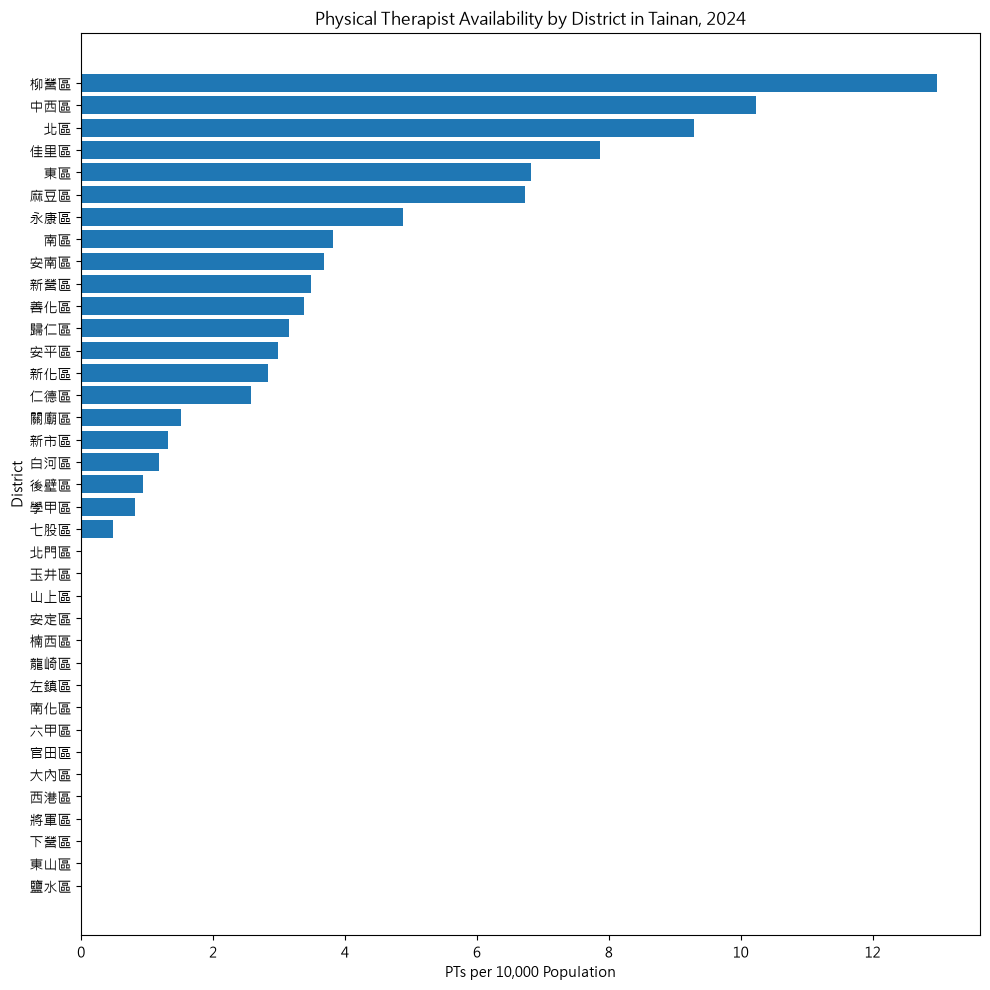

In [20]:
plt.figure(figsize=(10, 10))

plt.barh(
    df_pt_plot["district"],
    df_pt_plot["pt_per_10000"]
)

plt.xlabel("PTs per 10,000 Population")
plt.ylabel("District")
plt.title("Physical Therapist Availability by District in Tainan, 2024")

#先存
plt.tight_layout()
plt.savefig(
    "../docs/pt_per_10000_by_district.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

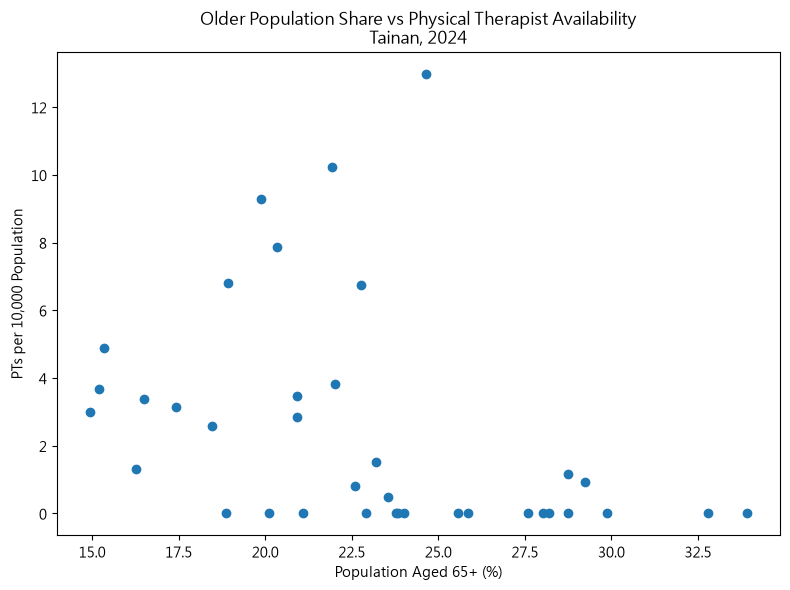

In [ ]:
#高齡人口比例較高的行政區，PT 相對供給是否也比較高？
plt.figure(figsize=(8, 6))

plt.scatter(
    df_master["pct_65_plus"],
    df_master["pt_per_10000"]
)

plt.xlabel("Population Aged 65+ (%)")
plt.ylabel("PTs per 10,000 Population")
plt.title("Older Population Share vs Physical Therapist Availability\nTainan, 2024")

plt.tight_layout()
plt.show()

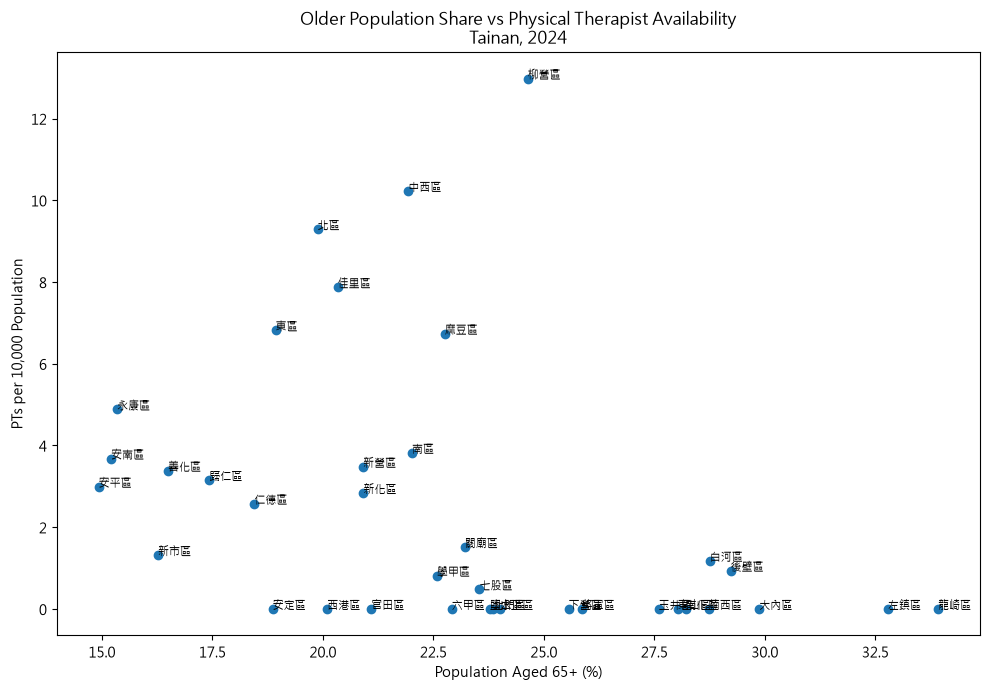

In [14]:
#含行政區版
plt.figure(figsize=(10, 7))

plt.scatter(
    df_master["pct_65_plus"],
    df_master["pt_per_10000"]
)

for _, row in df_master.iterrows():
    plt.annotate(
        row["district"],
        (row["pct_65_plus"], row["pt_per_10000"]),
        fontsize=8
    )

plt.xlabel("Population Aged 65+ (%)")
plt.ylabel("PTs per 10,000 Population")
plt.title("Older Population Share vs Physical Therapist Availability\nTainan, 2024")

plt.tight_layout()
plt.show()

In [15]:
#所有點都畫，但只標「高齡比例較高 + PT 供給較低」的區
median_age = df_master["pct_65_plus"].median()
median_pt = df_master["pt_per_10000"].median()

print("Median 65+ share:", median_age)
print("Median PT per 10,000:", median_pt)

Median 65+ share: 22.75567323996005
Median PT per 10,000: 0.93694368968425


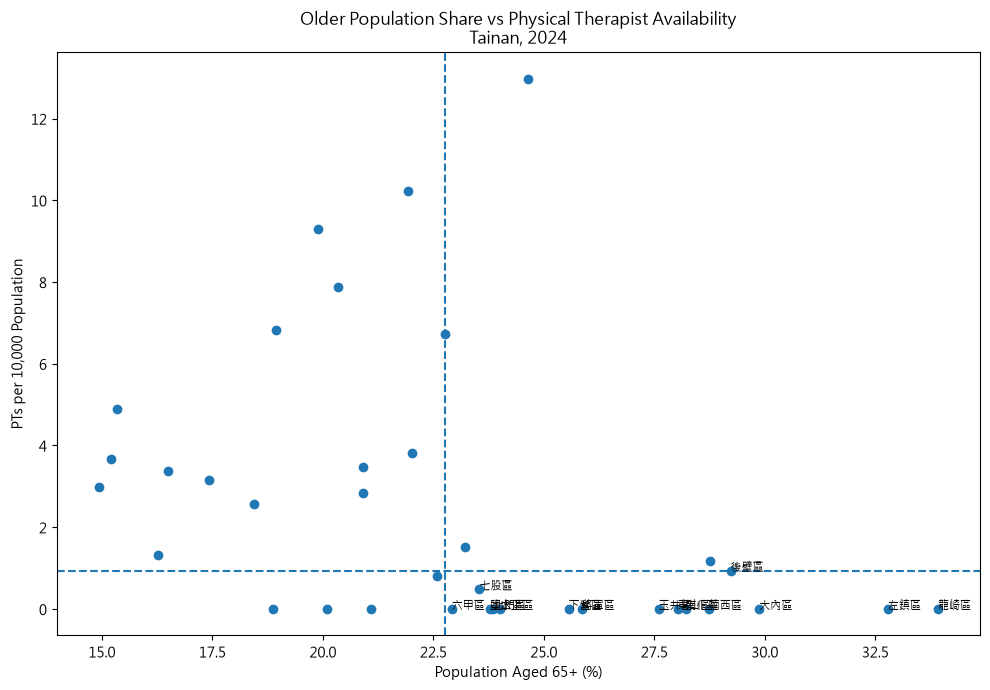

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df_master["pct_65_plus"],
    df_master["pt_per_10000"]
)

plt.axvline(
    median_age,
    linestyle="--"
)

plt.axhline(
    median_pt,
    linestyle="--"
)

for _, row in df_master.iterrows():

    if (
        row["pct_65_plus"] >= median_age
        and row["pt_per_10000"] <= median_pt
    ):
        plt.annotate(
            row["district"],
            (row["pct_65_plus"], row["pt_per_10000"]),
            fontsize=8
        )

plt.xlabel("Population Aged 65+ (%)")
plt.ylabel("PTs per 10,000 Population")
plt.title(
    "Older Population Share vs Physical Therapist Availability\n"
    "Tainan, 2024"
)

plt.tight_layout()
plt.show()

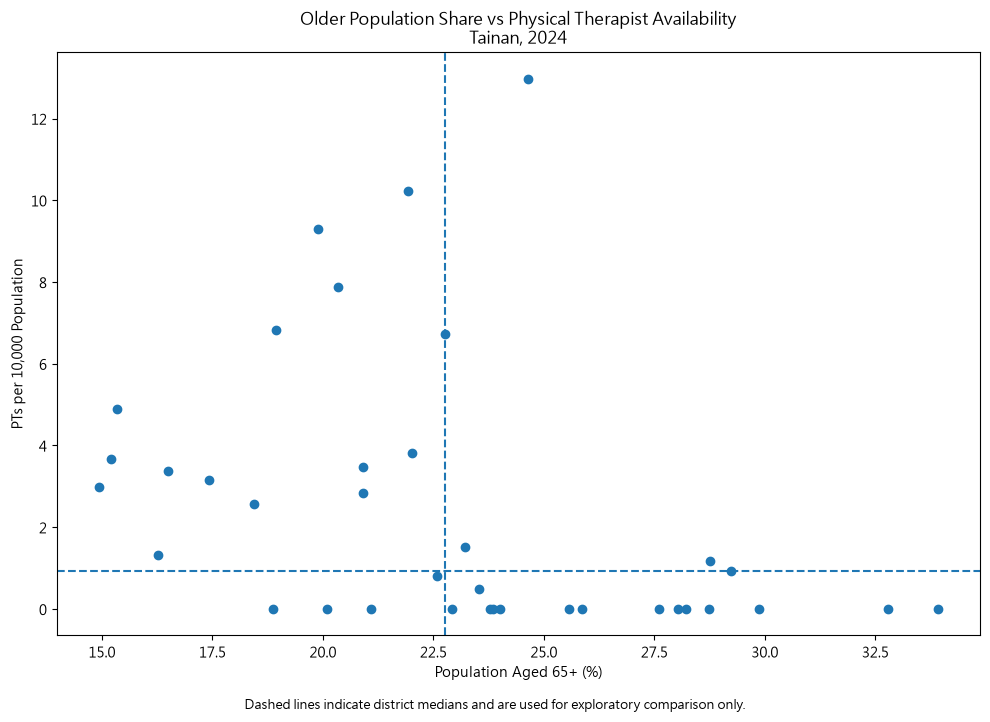

In [21]:
#scatter + median 虛線 + 不標／只標極少數行政區
median_age = df_master["pct_65_plus"].median()
median_pt = df_master["pt_per_10000"].median()

plt.figure(figsize=(10, 7))

plt.scatter(
    df_master["pct_65_plus"],
    df_master["pt_per_10000"]
)

plt.axvline(
    median_age,
    linestyle="--"
)

plt.axhline(
    median_pt,
    linestyle="--"
)

plt.xlabel("Population Aged 65+ (%)")
plt.ylabel("PTs per 10,000 Population")
plt.title(
    "Older Population Share vs Physical Therapist Availability\n"
    "Tainan, 2024"
)

plt.figtext(
    0.5,
    -0.02,
    "Dashed lines indicate district medians and are used for exploratory comparison only.",
    ha="center",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "../docs/older_population_vs_pt_availability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [2]:
df_population = pd.read_csv(
    "../data/processed/population_tainan_2024_clean.csv"
)

df_pt = pd.read_csv(
    "../data/processed/pt_workforce_tainan_2024_clean.csv"
)

df_clinic = pd.read_csv(
    "../data/processed/rehab_clinics_tainan_2024_clean.csv"
)

df_hospital = pd.read_csv(
    "../data/processed/rehab_hospitals_tainan_2024_clean.csv"
)

In [ ]:
#第三張：Rehabilitation Medical Facilities per 10,000(醫療機構供給)
df_facility_plot = df_master.sort_values(
    "rehab_medical_facility_per_10000",
    ascending=True
)

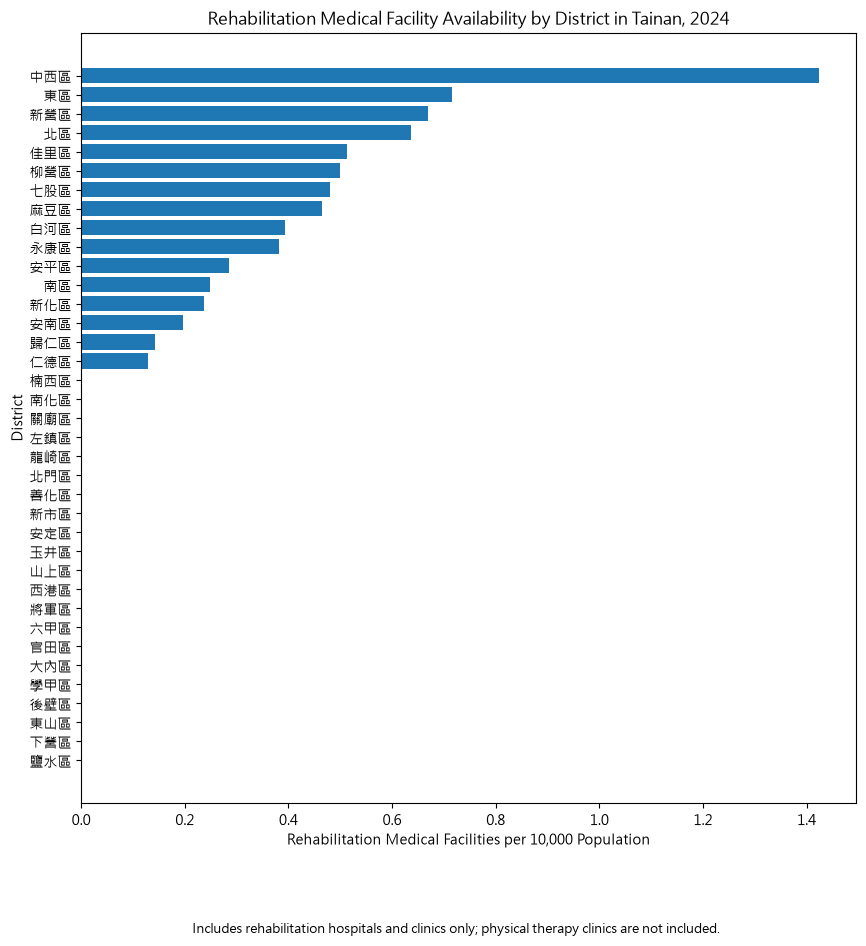

In [19]:
plt.figure(figsize=(10, 10))

plt.barh(
    df_facility_plot["district"],
    df_facility_plot["rehab_medical_facility_per_10000"]
)

plt.xlabel("Rehabilitation Medical Facilities per 10,000 Population")
plt.ylabel("District")
plt.title(
    "Rehabilitation Medical Facility Availability by District in Tainan, 2024"
)

plt.figtext(
    0.5,
    -0.02,
    "Includes rehabilitation hospitals and clinics only; "
    "physical therapy clinics are not included.",
    ha="center",
    fontsize=9
)

# 先存
plt.savefig(
    "../docs/rehab_medical_facility_per_10000_by_district.png",
    dpi=300,
    bbox_inches="tight"
)

# 再顯示
plt.show()

In [3]:
print("population:", df_population.shape)
print("PT:", df_pt.shape)
print("clinic:", df_clinic.shape)
print("hospital:", df_hospital.shape)

population: (37, 4)
PT: (37, 2)
clinic: (37, 2)
hospital: (37, 2)


In [4]:
print(df_population.columns.tolist())
print(df_pt.columns.tolist())
print(df_clinic.columns.tolist())
print(df_hospital.columns.tolist())

['district', 'total_population', 'population_65_plus', 'pct_65_plus']
['district', 'pt_count']
['district', 'rehab_clinic_count']
['district', 'rehab_hospital_count']


In [5]:
datasets = {
    "population": df_population,
    "pt": df_pt,
    "clinic": df_clinic,
    "hospital": df_hospital
}

population_districts = set(df_population["district"])

for name, df in datasets.items():
    current_districts = set(df["district"])

    missing = population_districts - current_districts
    extra = current_districts - population_districts

    print(name)
    print("  missing:", missing)
    print("  extra:", extra)

population
  missing: set()
  extra: set()
pt
  missing: set()
  extra: set()
clinic
  missing: set()
  extra: set()
hospital
  missing: set()
  extra: set()


In [6]:
for name, df in datasets.items():
    print(
        name,
        "duplicate:",
        df["district"].duplicated().sum(),
        "missing:",
        df["district"].isna().sum()
    )

population duplicate: 0 missing: 0
pt duplicate: 0 missing: 0
clinic duplicate: 0 missing: 0
hospital duplicate: 0 missing: 0


In [7]:
set(df_population["district"]) == set(df_pt["district"])

True

In [8]:
set(df_population["district"]) == set(df_clinic["district"])

True

In [9]:
set(df_population["district"]) == set(df_hospital["district"])

True

In [10]:
df_master = (
    df_population
    .merge(df_pt, on="district", how="left")
    .merge(df_clinic, on="district", how="left")
    .merge(df_hospital, on="district", how="left")
)

In [11]:
df_master.shape

(37, 7)

In [12]:
df_master.isna().sum()

district                0
total_population        0
population_65_plus      0
pct_65_plus             0
pt_count                0
rehab_clinic_count      0
rehab_hospital_count    0
dtype: int64

In [13]:
df_master["district"].duplicated().sum()

np.int64(0)

In [14]:
output_path = "../data/processed/master_table_tainan_2024_v1.csv"

df_master.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

In [15]:
df_master = pd.read_csv(
    "../data/processed/master_table_tainan_2024_v1.csv"
)

In [16]:
df_master["pt_per_10000"] = (
    df_master["pt_count"]
    / df_master["total_population"]
    * 10000
)

In [17]:
df_master[
    ["district", "total_population", "pt_count", "pt_per_10000"]
].sort_values("pt_per_10000").head(10)

,district,total_population,pt_count,pt_per_10000
1,鹽水區,23984,0,0.0
5,東山區,18866,0,0.0
7,下營區,22099,0,0.0
15,將軍區,18102,0,0.0
13,西港區,25037,0,0.0
10,大內區,8606,0,0.0
9,官田區,20675,0,0.0
8,六甲區,21140,0,0.0
24,南化區,7800,0,0.0
25,左鎮區,4136,0,0.0


In [18]:
df_master[
    ["district", "total_population", "pt_count", "pt_per_10000"]
].sort_values("pt_per_10000").head(10).round(2)

,district,total_population,pt_count,pt_per_10000
1,鹽水區,23984,0,0.0
5,東山區,18866,0,0.0
7,下營區,22099,0,0.0
15,將軍區,18102,0,0.0
13,西港區,25037,0,0.0
10,大內區,8606,0,0.0
9,官田區,20675,0,0.0
8,六甲區,21140,0,0.0
24,南化區,7800,0,0.0
25,左鎮區,4136,0,0.0
